## Breast Cancer scRNA-seq Analysis: Triple Negative vs Normal
**Characterizing the tumor microenvironment of Triple Negative Breast Cancer (TNBC) using single-cell RNA sequencing.** 

A breast cancer tumor is made of many cell types, including the actual cancer cells, immune cells that are attempting to fight the cancer, fibroblasts that have been recruited by the cancer cells, blood vessel cells to provide nutrients to the tumor, and many others. This mix of cells is known as the tumor microenvironment. 
This project aims to use single-cell RNA sequencing to determine what cell types exist in TNBC tumors, how many of each exist, which are unique to the tumor, which exist in normal tissue, and what genes these cells are expressing. TNBC is the most aggressive breast cancer subtype, as these tumors lack estrogen receptors, progesterone receptors, and HER2 expression. This makes them untreatable with hormone or targeted therapies, so further understanding these tumors at the cellular level can have direct clinical relevance. 

**Dataset:** GSE161529 (GEO): 117,232 cells (13 normal samples and 8 TNBC tumor samples) 
**Reference:** Wu, S.Z. et al. A single-cell and spatially resolved atlas of human breast cancers. Nature Genetics, 2021. https://doi.org/10.1038/s41588-021-00911-1  
**Processing:** See 01_data_processing.ipynb for full pipeline  
**Tools:** Scanpy 1.11.5, Python 3.10

In [1]:
#import libraries for analysis and plotting
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#shows progress messages while functions run
sc.settings.verbosity = 3 
#set default figure appearance for white background and standard resolution
sc.settings.set_figure_params(dpi=80, facecolor='white') 
#load the processed and annotated dataset saved from 01_data_processing_ipynb, including QC filtering, normalization, PCA, UMAP, clustering, and cell type labels
adata = sc.read('../data/breast_cancer_annotated.h5ad')
#confirm cell counts and condition balance before continuing
print(adata)
print(f"\nCondition counts:")
print(adata.obs['condition'].value_counts())

AnnData object with n_obs × n_vars = 117232 × 2499
    obs: 'sample', 'condition', 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'cell_type_colors', 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

Condition counts:
condition
Tumor_TN    59362
Normal      57870
Name: count, dtype: int64


## Dataset Overview:
After quality control filtering, we kept 117,232 cells across 21 patients (57,870 normal and 59,362 TNBC tumor cells). The dataset is well-balanced between conditions, which is important for fair comparison.

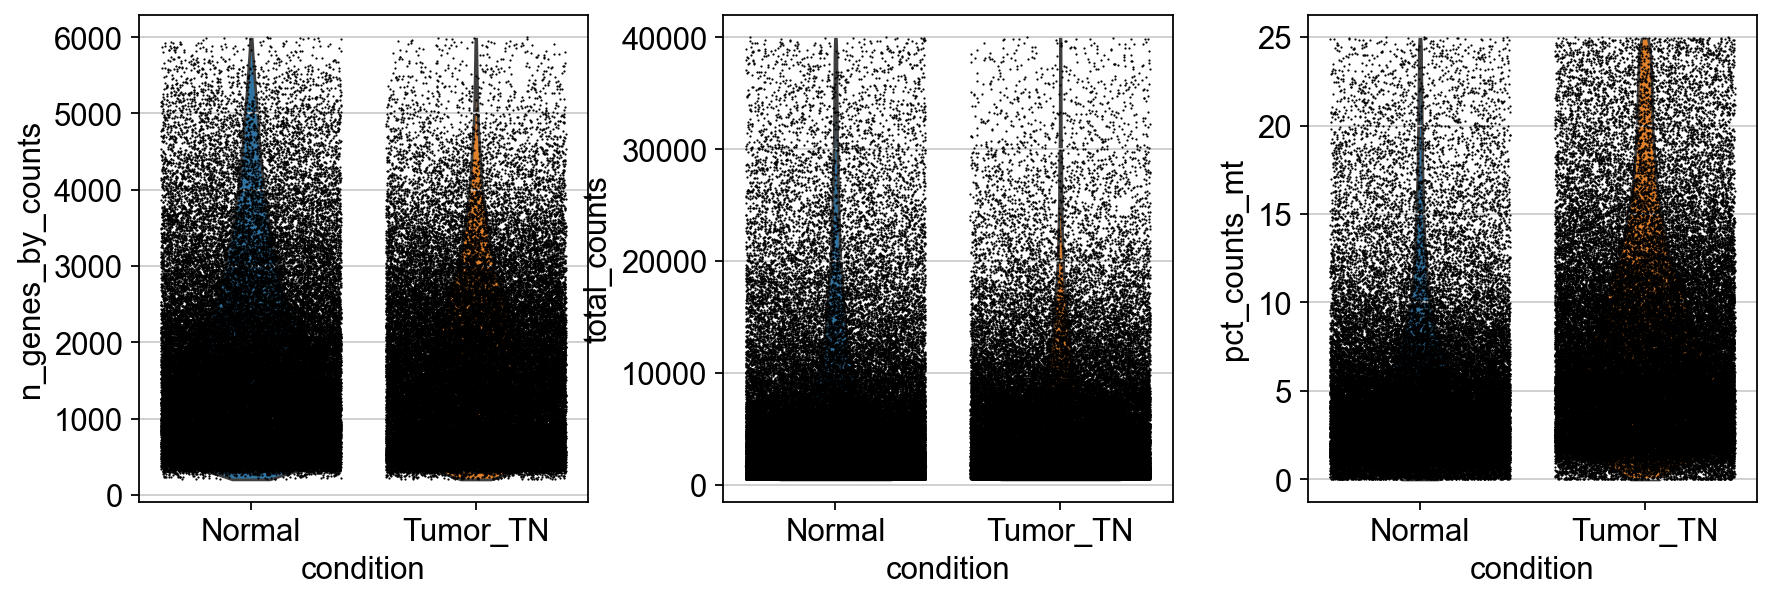

In [2]:
# visualize QC metrics split by condition to check data quality after filtering
# n_genes_by_counts: the number of genes detected per cell
# total_counts: total RNA molecules detected per cell
# pct_counts_mt: percentage of counts from mitochondrial cells (high levels indicate dying cells)
# groupby = 'condition' shows Normal vs Tumor_TN side by side
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, groupby='condition',
             save='_qc_metrics.png')

## Violin Plots
QC metrics appear to be clean across both conditions. Tumor cells show higher mitochondrial percentages than normal cells, which is expected since cancer cells are known to have altered mitochondrial activity as part of metabolic reprogramming. The cutoff was set to 25% rather than 5% typically used for blood cells, since tumor tissue has higher mitochondrial expression.

## Dimensionality Reduction and Clustering
PCA (Principal Component Analysis) takes 2,499 highly variable genes per cell and compresses them into a smaller number of new variables known as principal components (PCs) that each capture a major source of variation across the cells. We used 30 PCs rather than the standard 10 because the variance ratio plot showed that the curve was still declining at PC30, suggesting that there was more complex biological variation than a blood cell dataset. We then created a UMAP that takes these 30 numbers and converts them into a 2D visualization using the 15 nearest neighbors. 

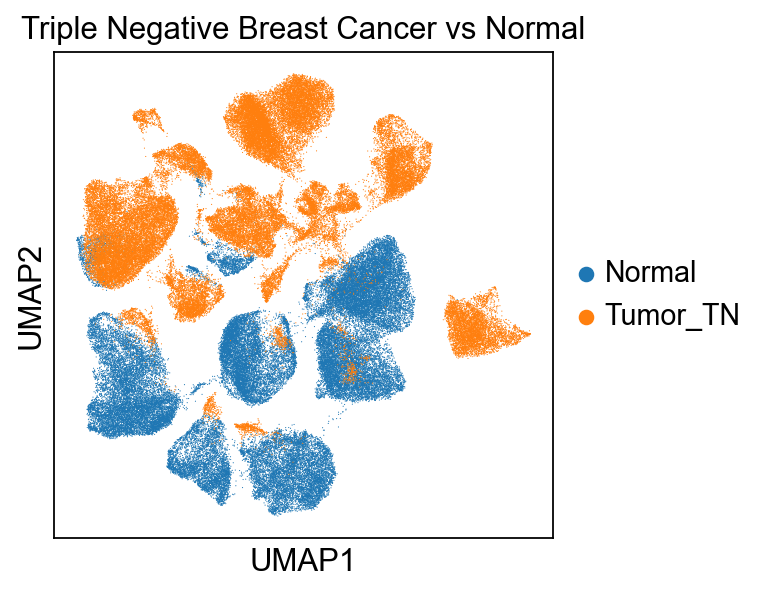

In [3]:
# plot UMAP colored by condition (Normal vs Tumor_TN
# look at whether tumor and normal cells separate in the embedding
sc.pl.umap(adata, color='condition',
           title='Triple Negative Breast Cancer vs Normal',
           save='_condition.png')

## UMAP
The UMAP shows that tumor and normal cells are mostly separated with some overlap. Clusters near the top are predominantly tumor cells, while clusters near the bottom are predominantly normal cells. A few clusters in the middle show mixing between conditions, which likely represents shared cell types like immune cells that are present in both normal and tumor tissue.

## Cell Type Annotation
Leiden clustering groups cells based on how similar their gene expression profiles are. Each cluster is then annotated by finding its marker genes, genes that are the most uniquely expressed in that cluster compared to all others, and matching them against known cell type signatures. This allows us to label each cluster with a real biological identity without prior knowledge of what cell types are present. Since we let the algorithm find the clusters without telling it what to look for, this is also known as unsupervised clustering. 

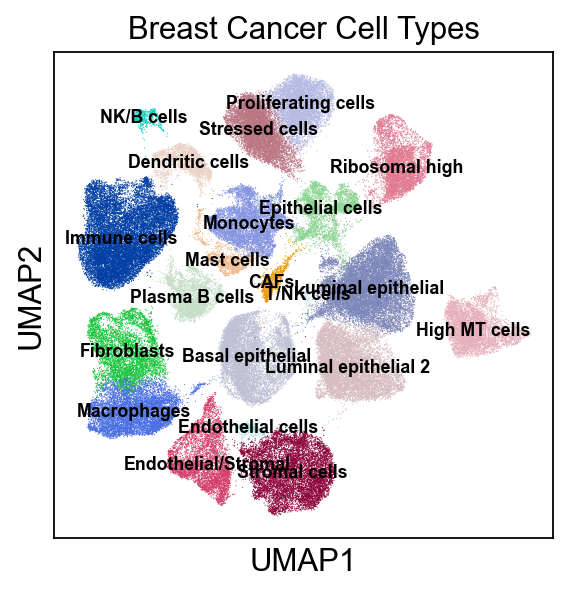

In [4]:
# plot UMAP which each cluster labeled by annotated cell type
# legend_loc = 'on data' places the labels directly on the clusters
# legend_fontsize=8 keeps the labels small enough to fit without overlapping
sc.pl.umap(adata, color='cell_type', legend_loc='on data',
           title='Breast Cancer Cell Types', legend_fontsize=8,
           save='_celltypes.png')

## Labeled UMAP
21 cell populations were identified using Leiden clustering and annotated by matching  marker genes against known cell type signatures. The tumor microenvironment contains a diverse mix of epithelial, immune, stromal, and vascular cell types. The stressed, proliferating, and immune cells are predominantly in the tumor-enriched region, while basal and luminal epithelial cells, as well as stromal and macrophages, are predominantly clustered in the normal-enriched region.

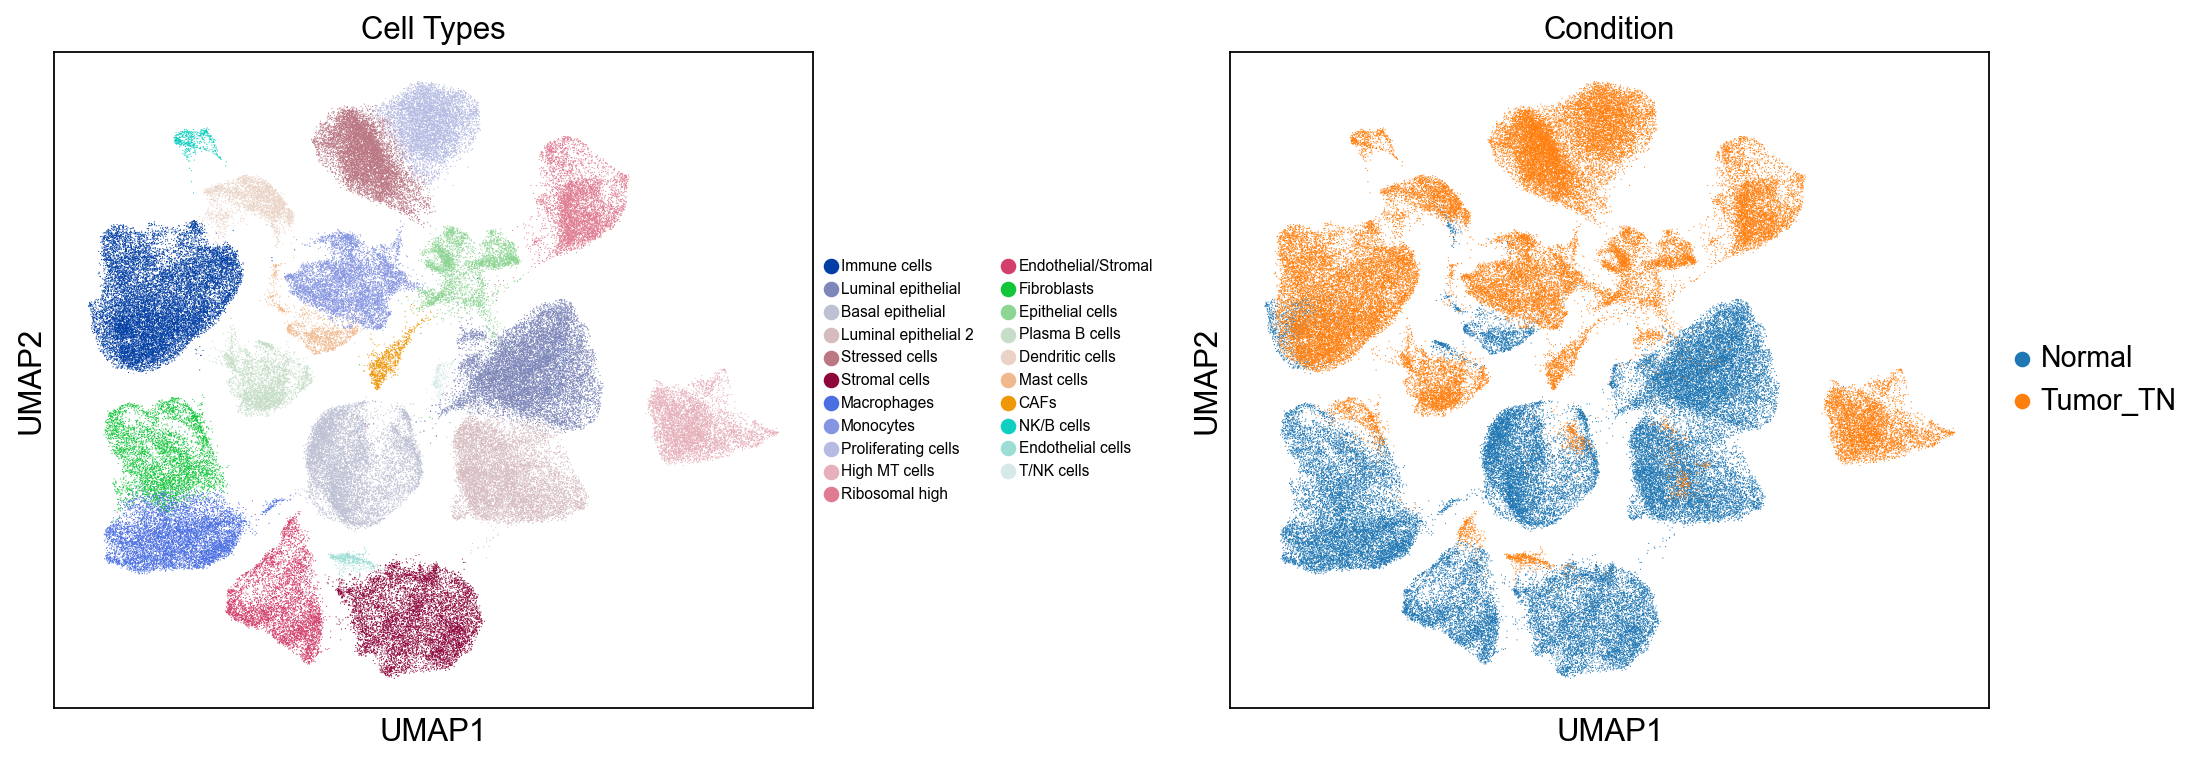

In [5]:
import matplotlib.pyplot as plt

# use matplotlib to control figure size since sc.pl.umap doesn't support figsize 
# placing both UMAPs side by side makes it easy to visually match cell types to conditions.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.umap(adata, color='cell_type', legend_fontsize=7, 
           title='Cell Types', ax=axes[0], show=False)
sc.pl.umap(adata, color='condition', 
           title='Condition', ax=axes[1], show=False)

plt.tight_layout()
plt.savefig('../figures/umap_celltypes_condition.png', dpi=150, bbox_inches='tight')
plt.show()

## Side-by-Side UMAP Comparison
Comparing the cell type UMAP with the condition UMAP shows which cell types are 
enriched in tumor vs normal tissue. Immune cells, stressed cells, proliferating 
cells, monocytes, and ribosomal high cells appear predominantly in the tumor. 
Normal tissue is enriched for luminal and basal epithelial cells, macrophages, 
stromal cells, and fibroblasts — the expected architecture of healthy breast tissue.

## Marker Gene Expression
Marker genes are genes that are uniquely and highly expressed in one cell type compared to all others and allow us to identify what each cluster is biologically. We are using a dot plot to show how well each maker gene performs. Ideally, we would see a large and dark dot only in the row that is supposed to be marked, and smaller pale dots elsewhere to confirm that our cell type annotations are correct.

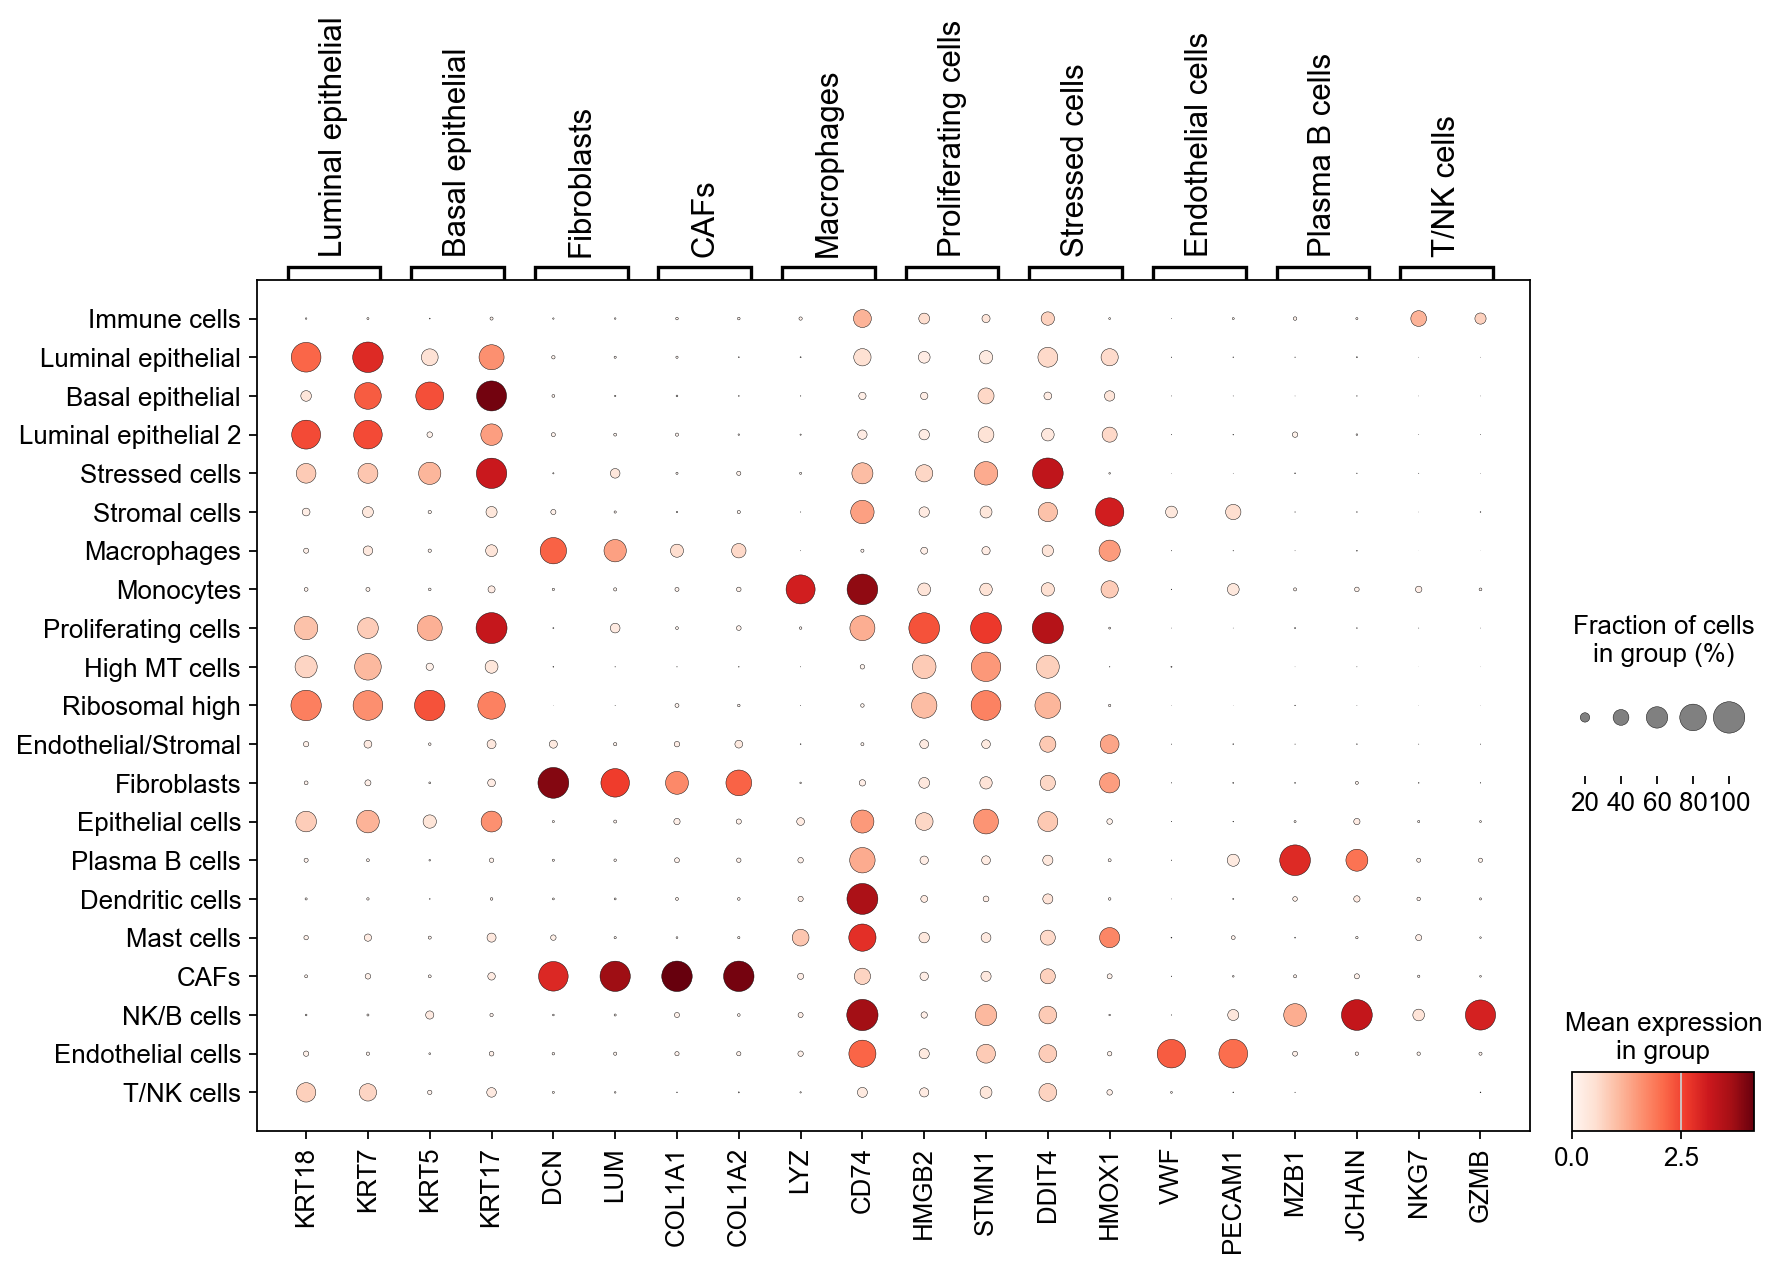

In [6]:
# dictionary of known marker genes for each cell type, where each key is a cell type, and each value is a list of canonical marker genes
# these were selected based on the top differentially expressed genes per cluster and validated against known cell type signatures in the literature 
# marker genes were selected from rank_gene_groups output in 01_data_processing.ipynb and validated against known cell type signatures (Wu et al. 2021)
marker_genes = {
    'Luminal epithelial': ['KRT18', 'KRT7'], #keratin genes expressed in luminal breast cells
    'Basal epithelial': ['KRT5', 'KRT17'], #keratins specific to basal/myoepithelial cells
    'Fibroblasts': ['DCN', 'LUM'], #extracellular matrix proteins
    'CAFs': ['COL1A1', 'COL1A2'], #collagen genes since cancer-associated fibroblasts produce excess collagen
    'Macrophages': ['LYZ', 'CD74'], #lysozyme and MHC-II associated protein
    'Proliferating cells': ['HMGB2', 'STMN1'], #cell division markers
    'Stressed cells': ['DDIT4', 'HMOX1'], #stress response genes
    'Endothelial cells': ['VWF', 'PECAM1'], #vascular markers
    'Plasma B cells': ['MZB1', 'JCHAIN'], #antibody secretion markers
    'T/NK cells': ['NKG7', 'GZMB'] #cytotoxic cell markers (granzyme B)
}

# dot plot: dot size = fraction of cells expressing the gene, color = mean expression
# good annotation is a large dot only in the expected row
sc.pl.dotplot(adata, marker_genes, groupby='cell_type',
              dendrogram=False,
              figsize=(12, 7),
              save='_marker_genes.png')

## Marker Gene Expression By Cell Type
**KRT17**, a basal epithelial marker, also shows expression in stressed and proliferating cells. This is consistent with TNBC being classified as a basal-like breast cancer, meaning the tumor cells retain basal keratin expression even as they become cancerous.
**DCN (Decorin)** is a fibroblast marker that shows expression in both fibroblasts and CAFs. This is expected since CAFs are derived from normal fibroblasts that have been reprogrammed by the tumor microenvironment to retain fibroblast markers while taking on a tumor-supportive role. 
**CD74** shows high expression across multiple immune cell types, including NK/B cells, dendritic cells, and monocytes, with lower expression in mast cells and endothelial cells. CD74 is an MHC class II-associated protein involved in antigen presentation, so its expression across immune populations is expected and confirms that the immune cell annotations are correct.
**DDIT4** is a hypoxia and stress response gene and shows high expression in both stressed and proliferating cells. Rapidly dividing tumor cells consume oxygen faster than it can be supplied, creating hypoxic conditions. The stressed cells likely represent the result of metabolic stress in the tumor core. 
**HMOX1**, an oxidative stress response gene, shows expression in stromal cells in addition to stressed cells. HMOX1 upregulation in tumor stromal cells is consistent with the tumor microenvironment creating oxidative stress that affects surrounding non-cancerous cells. Stromal HMOX1 expression has also been associated with tumor progression, suggesting the stroma can play a protective role for the tumor.
**JCHAIN** is an antibody assembly marker that shows expression in NK/B cells, in addition to plasma B cells. This suggests that the NK/B cluster contains a mix of NK cells and B cells that weren't fully separated by Leiden clustering. The JCHAIN signal is likely coming from the B cell component. This is a known limitation of unsupervised clustering, and increasing the resolution parameter could separate these populations further.

## Tumor vs Normal Cell Type Composition
UMAPs show where cells are spatially, but lack numbers. Creating a proportions table will produce the counts and percentages to make conclusions about cell types being in tumor or normal cells.

In [7]:
# group cells by cell type and condition and count how many cells fall into each combination
proportions = adata.obs.groupby(['cell_type', 'condition'], observed=False).size().unstack(fill_value=0)
# calculate total cells per cell type and percentage from each condition
proportions['total'] = proportions.sum(axis=1)
proportions['pct_tumor'] = (proportions['Tumor_TN'] / proportions['total'] * 100).round(1)
proportions['pct_normal'] = (proportions['Normal'] / proportions['total'] * 100).round(1)

# sort by tumor percentage so most tumor-enriched cell types are first
print(proportions[['Normal', 'Tumor_TN', 'pct_normal', 'pct_tumor']].sort_values('pct_tumor', ascending=False))

condition             Normal  Tumor_TN  pct_normal  pct_tumor
cell_type                                                    
Ribosomal high             0      5173         0.0      100.0
NK/B cells                 0       523         0.0      100.0
CAFs                       0       908         0.0      100.0
Stressed cells             0      8333         0.0      100.0
Proliferating cells        0      6271         0.0      100.0
High MT cells              1      5343         0.0      100.0
Monocytes                 54      6278         0.9       99.1
Epithelial cells          53      3615         1.4       98.6
Dendritic cells          108      2331         4.4       95.6
Plasma B cells           224      3126         6.7       93.3
Immune cells            1064     14884         6.7       93.3
Endothelial cells         31       427         6.8       93.2
Fibroblasts             4033       725        84.8       15.2
Mast cells              1137       120        90.5        9.5
Endothel

## Tumor vs Normal Cell Type Composition
Cells that exist in 100% of tumor cells and 0% normal cells are significant as they don't exist in normal breast tissue, only when cancer is present. Proliferating cells, stressed cells, CAFs, NK/B cells, and High MT cells are all in this category, meaning these cell states are created by the cancer itself. Furthermore, Endothelial/Stromal, Luminal Epithelial 2, Basal Epithelial, T/NK cells, Luminal Epithelial, Stromal, and Macrophages exist in less than 10% of tumor cells. These cells represent normal breast tissue architecture that is largely replaced or absent in TNBC tumors.

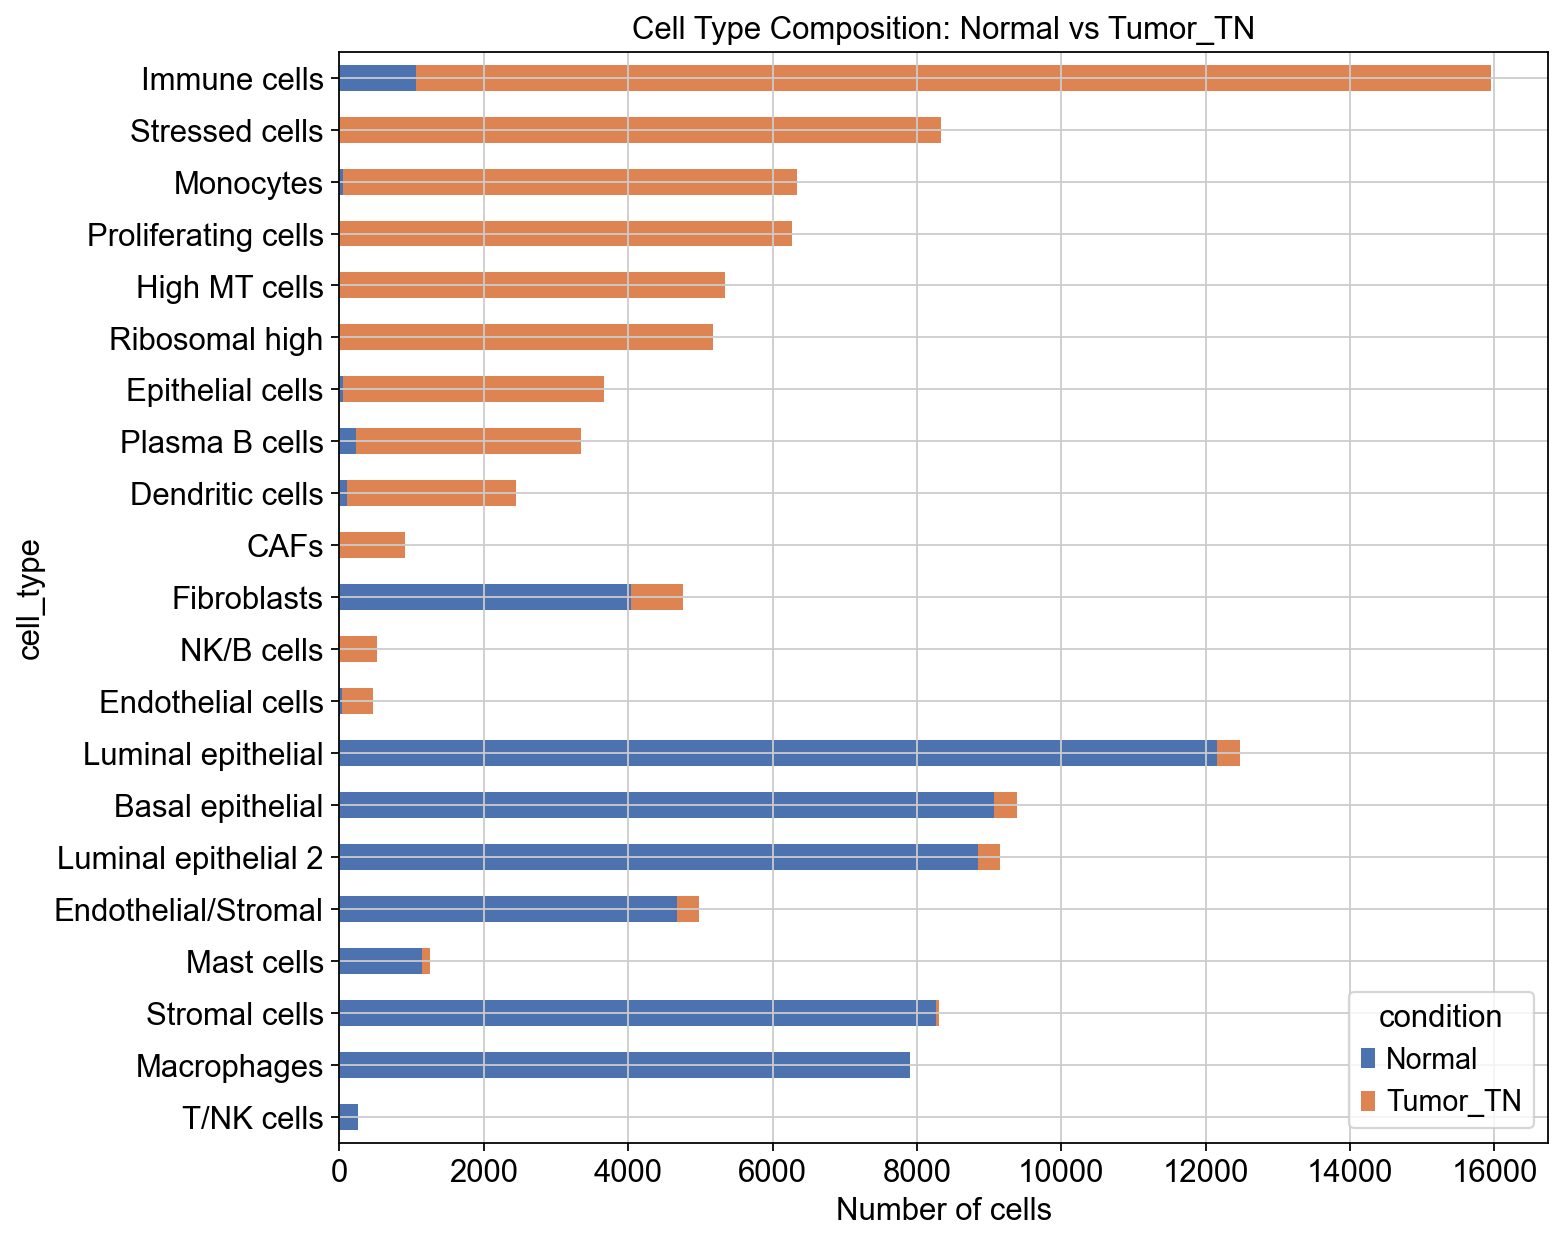

In [8]:
# create a stacked horizontal bar chart showing cell counts per condition for each cell type, sorted by tumor cell count so most tumor-enriched cell types appear at the top
# blue = Normal, orange = Tumor_TN
ax = proportions[['Normal', 'Tumor_TN']].sort_values('Tumor_TN').plot(
    kind='barh', #horizontal bars are easier to read
    stacked=True, #stacked so you can see total cells and condition split at once
    figsize=(10, 8),
    color=['#4C72B0', '#DD8452']
)
plt.title('Cell Type Composition: Normal vs Tumor_TN', fontsize=14)
plt.xlabel('Number of cells')
plt.tight_layout()
plt.savefig('../figures/cell_type_proportions.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell Type Composition
The bar chart shows that, although not existing only in tumor cells, there are the most immune cells in a tumor. This is likely due to tumor immune infiltration, meaning the immune system is actively trying to fight the cancer. This suggests that the immune system has recognized the tumor and sent cells to attack it. Despite all these immune cells, the tumor is still growing, suggesting that it has found ways to evade or suppress the immune response. This is a major area of TNBC research, and why immunotherapy is being explored as a treatment. 

## Key Findings
**Tumor-enriched populations (100% tumor):**
The most significant finding is that several cell populations exist exclusively in tumor tissue. Proliferating cells (6,271 cells) reflect the cancer's hallmark, uncontrolled cell division. Stressed cells (8,333 cells) suggest that the tumor has a hypoxic core due to rapid growth outpacing blood supply, and CAFs (908 cells) are fibroblasts that have been reprogrammed to support the tumor's growth.
**Normal-enriched populations**
97% of Luminal and basal epithelial cells are found in normal cells, signifying that they are part of healthy breast tissue architecture, as well as 99.8% macrophages and 99.1% monocytes that show a shift in myeloid cell states between the tumor and normal microenvironment. 

These findings are consistent with published TNBC literature and reflect the aggressive, metabolically active nature of triple-negative breast cancer.